<a href="https://colab.research.google.com/github/Faith-moses/Prediction-of-Fake-News-Content-using-Content-and-Metadata-Features-for-AI-Models/blob/main/Moses_Faith_25949994_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries and Loading Dataset.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the charts
sns.set_theme(style="whitegrid")

import re
import nltk
from nltk.corpus import stopwords

#Download stopwords library
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the Bozkus (2022) data files
fake_df = pd.read_csv('/content/drive/MyDrive/archive(4)/News_dataset/Fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/archive(4)/News_dataset/True.csv')

##Fake News Inspection

In [4]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
fake_df['subject'].value_counts()

,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [7]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [8]:
fake_df.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


##True News Inspection

In [5]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [9]:
true_df['subject'].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145


In [10]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [11]:
true_df.describe()

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


#Labeling, Merging, Shuffling and Text preprocessing pipeline

In [12]:
# Apply binary labels: 0 for Fake, 1 for Real
fake_df['label'] = 0
true_df['label'] = 1

In [19]:
# Merge and shuffle the dataset to prevent ordering bias during training
news = pd.concat([fake_df, true_df], ignore_index=True)
news = news.sample(frac=1, random_state=42).reset_index(drop=True)

In [20]:
# Drop rows where the text body is completely missing
news = news.dropna(subset=['text'])

In [21]:
print(f"Total articles loaded: {len(news)}")

Total articles loaded: 44898


In [16]:
#text sanitization
def clean_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenise and remove stop-words
    tokens = text.split()
    clean_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(clean_tokens)

In [22]:
# Apply the cleaning function to the article body
news['clean_text'] = news['text'].apply(clean_text)

In [24]:
print("Text preprocessing complete.")
print(news[['text', 'clean_text', 'label']].head(10))

Text preprocessing complete.
                                                text  \
0  21st Century Wire says Ben Stein, reputable pr...   
1  WASHINGTON (Reuters) - U.S. President Donald T...   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...   
3  On Monday, Donald Trump once again embarrassed...   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...   
5  On Wednesday, Democrats took a powerful stance...   
6  President Trump s rally in FL on Saturday was ...   
7  He s been Europe s version of the outspoken Te...   
8  WASHINGTON (Reuters) - The State Department sa...   
9   (This version of the story corrects the figur...   

                                          clean_text  label  
0  21st century wire says ben stein reputable pro...      0  
1  washington reuters us president donald trump r...      1  
2  reuters puerto rico governor ricardo rossello ...      1  
3  monday donald trump embarrassed country accide...      0  
4  glasgow scotland reuters us presidential 

#Proxy Feature Engineering

In [25]:
#library that handles complex
!pip install textstat textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.2 MB/s eta 0:00:00


In [26]:
#library to generate the engineered metadata features
import textstat
from textblob import TextBlob

In [27]:
# 1. Headline Length (Quantity Feature)
news['title_length'] = news['title'].apply(lambda x: len(str(x).split()))

In [28]:
# 2. Sentiment Polarity (Psycho-linguistic Feature)
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

news['sentiment_score'] = news['clean_text'].apply(get_sentiment)

In [29]:
# 3. Readability Index (Stylometric/Complexity Feature)
def get_readability(text):
    # Restrict to first 500 characters to prevent RAM timeouts on 44,000 rows
    return textstat.flesch_reading_ease(str(text)[:500])

news['readability_score'] = news['text'].apply(get_readability)

In [30]:
print("Feature engineering complete.")
print(news[['title_length', 'sentiment_score', 'readability_score', 'label']].head())

Feature engineering complete.
   title_length  sentiment_score  readability_score  label
0            14         0.057692          40.842886      0
1             8         0.104893          25.174009      1
2            10         0.001716          50.209895      1
3            12        -0.024554          27.460495      0
4            10         0.025200          49.542727      1


#EDA

In [56]:
news.head()

,title,text,subject,date,label,clean_text,title_length,sentiment_score,readability_score
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,21st century wire says ben stein reputable pro...,14,0.057692,40.842886
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,washington reuters us president donald trump r...,8,0.104893,25.174009
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,reuters puerto rico governor ricardo rossello ...,10,0.001716,50.209895
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,monday donald trump embarrassed country accide...,12,-0.024554,27.460495
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,glasgow scotland reuters us presidential candi...,10,0.025200,49.542727


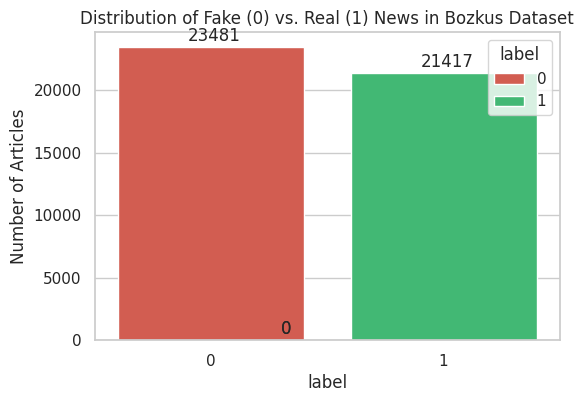

In [58]:
# Visualize the Target Variable Distribution (Class Balance)
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=news, hue= 'label',palette=['#e74c3c', '#2ecc71'])
plt.title('Distribution of Fake (0) vs. Real (1) News in Bozkus Dataset')
plt.ylabel('Number of Articles')

# Add actual counts to the top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))
plt.show()

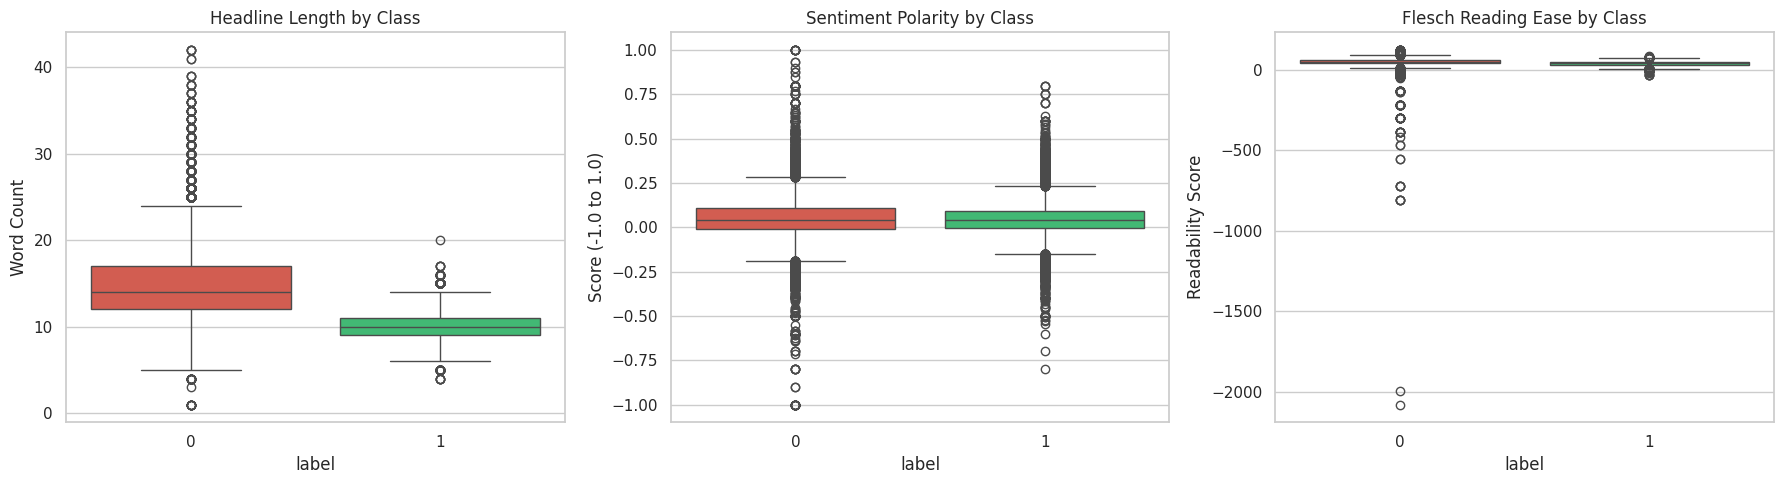

In [61]:
# Visualize the Distributions of Engineered Proxy Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Headline Length
sns.boxplot(x='label', y='title_length', data=news, ax=axes[0], hue='label', palette=['#e74c3c', '#2ecc71'], legend=False)
axes[0].set_title('Headline Length by Class')
axes[0].set_ylabel('Word Count')

# Sentiment Polarity
sns.boxplot(x='label', y='sentiment_score', data=news, ax=axes[1], hue='label', palette=['#e74c3c', '#2ecc71'], legend=False)
axes[1].set_title('Sentiment Polarity by Class')
axes[1].set_ylabel('Score (-1.0 to 1.0)')

# Readability Index
sns.boxplot(x='label', y='readability_score', data=news, ax=axes[2], hue='label', palette=['#e74c3c', '#2ecc71'], legend=False)
axes[2].set_title('Flesch Reading Ease by Class')
axes[2].set_ylabel('Readability Score')

plt.tight_layout()
plt.show()

#TF-IDF vectorization and Data splitting

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [32]:
# Initialize the TF-IDF Vectorizer
# Capping features at 10,000 to prevent Google Colab RAM timeouts
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

In [33]:
# Fit and transform the sanitized text into a sparse mathematical matrix
X_text = tfidf_vectorizer.fit_transform(news['clean_text'])

In [34]:
# Isolate the target variable
y = news['label']

In [35]:
# Split the data into 80% training and 20% testing sets
# stratify=y ensures the same ratio of fake to real news exists in both splits
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y
)

In [36]:
print(f"TF-IDF matrix shape: {X_text.shape}")
print(f"Training set size: {X_train_text.shape} articles")
print(f"Testing set size: {X_test_text.shape} articles")

TF-IDF matrix shape: (44898, 10000)
Training set size: (35918, 10000) articles
Testing set size: (8980, 10000) articles


#Model Evaluation

## Text-only Baseline Evaluation
Logistic Regression, Random Forest, and Naïve Bayes algorithms

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [38]:
# Initialize the three baseline algorithms
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
nb_model = MultinomialNB()

In [41]:
# Train (fit) the models on the 80% training matrix
print("Training Logistic Regression...")
log_reg.fit(X_train_text, y_train)

Training Logistic Regression...


LogisticRegression(max_iter=1000, random_state=42)

In [42]:
print("Training Random Forest...")
rf_model.fit(X_train_text, y_train)

Training Random Forest...


RandomForestClassifier(n_jobs=-1, random_state=42)

In [43]:
print("Training Naïve Bayes...")
nb_model.fit(X_train_text, y_train)

Training Naïve Bayes...


MultinomialNB()

In [44]:
# Evaluate the models on the 20% unseen testing data
models = {'Logistic Regression': log_reg, 'Random Forest': rf_model, 'Naïve Bayes': nb_model}

for name, model in models.items():
    # Force the trained model to predict labels for the unseen test articles
    predictions = model.predict(X_test_text)

    # Calculate how many predictions matched the actual hidden labels
    acc = accuracy_score(y_test, predictions)
    print(f"\n=== {name} Performance ===")
    print(f"Accuracy: {acc:.4f}")

    # Generate a detailed statistical breakdown
    print(classification_report(y_test, predictions, target_names=['Fake (0)', 'Real (1)']))


=== Logistic Regression Performance ===
Accuracy: 0.9899
              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99      4696
    Real (1)       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


=== Random Forest Performance ===
Accuracy: 0.9978
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      4696
    Real (1)       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980


=== Naïve Bayes Performance ===
Accuracy: 0.9432
              precision    recall  f1-score   support

    Fake (0)       0.95      0.94      0.95      4696
    Real (1)       0.94      0.94      0.94      4284

    accuracy          

## Metadata-Only Training
same algorithm

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

In [46]:
# Isolate the engineered proxy metadata features
X_meta = news[['title_length', 'sentiment_score', 'readability_score']]

In [48]:
# Split the metadata using the exact same random state to maintain identical testing groups
X_train_meta, X_test_meta, y_train, y_test = train_test_split(
    X_meta, y, test_size=0.20, random_state=42, stratify=y)

In [49]:
# Scale the features to prevent algorithms from prioritizing larger numbers (like length) over smaller ones (like sentiment)
scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)
X_test_meta_scaled = scaler.transform(X_test_meta)

In [50]:
# Initialize Gaussian Naive Bayes (MultinomialNB fails on negative sentiment scores)
gnb_model = GaussianNB()

In [51]:
# Train the models on METADATA ONLY
print("Training Tier 2 Models (Metadata Only)...")
log_reg.fit(X_train_meta_scaled, y_train)
rf_model.fit(X_train_meta_scaled, y_train)
gnb_model.fit(X_train_meta_scaled, y_train)

Training Tier 2 Models (Metadata Only)...


GaussianNB()

In [52]:
# Evaluate the models
models_meta = {'Logistic Regression': log_reg, 'Random Forest': rf_model, 'Gaussian Naïve Bayes': gnb_model}

for name, model in models_meta.items():
    # Predict labels using ONLY the metadata
    predictions = model.predict(X_test_meta_scaled)

    # Calculate performance
    acc = accuracy_score(y_test, predictions)
    print(f"\n=== {name} (Metadata Only) Performance ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions, target_names=['Fake (0)', 'Real (1)']))


=== Logistic Regression (Metadata Only) Performance ===
Accuracy: 0.8105
              precision    recall  f1-score   support

    Fake (0)       0.84      0.79      0.81      4696
    Real (1)       0.78      0.83      0.81      4284

    accuracy                           0.81      8980
   macro avg       0.81      0.81      0.81      8980
weighted avg       0.81      0.81      0.81      8980


=== Random Forest (Metadata Only) Performance ===
Accuracy: 0.8549
              precision    recall  f1-score   support

    Fake (0)       0.86      0.86      0.86      4696
    Real (1)       0.85      0.85      0.85      4284

    accuracy                           0.85      8980
   macro avg       0.85      0.85      0.85      8980
weighted avg       0.85      0.85      0.85      8980


=== Gaussian Naïve Bayes (Metadata Only) Performance ===
Accuracy: 0.8084
              precision    recall  f1-score   support

    Fake (0)       0.91      0.70      0.79      4696
    Real (1)       0

## Feature Fusion Training

In [62]:
from scipy.sparse import hstack

# Horizontally stack the sparse TF-IDF matrix with the dense scaled metadata array
X_train_hybrid = hstack([X_train_text, X_train_meta_scaled])
X_test_hybrid = hstack([X_test_text, X_test_meta_scaled])

print(f"Hybrid Matrix Shape: {X_train_hybrid.shape}")

Hybrid Matrix Shape: (35918, 10003)


In [63]:
# Train the models on the hybrid data
# Note: Gaussian Naïve Bayes is deliberately excluded here. It requires dense matrices,
# and converting a 10,003-column matrix to dense format will instantly crash Google Colab's RAM.
print("Training Logistic Regression (Hybrid)...")
log_reg.fit(X_train_hybrid, y_train)

print("Training Random Forest (Hybrid)...")
rf_model.fit(X_train_hybrid, y_train)

Training Logistic Regression (Hybrid)...
Training Random Forest (Hybrid)...


RandomForestClassifier(n_jobs=-1, random_state=42)

In [64]:
# Evaluate the hybrid models
models_hybrid = {'Logistic Regression': log_reg, 'Random Forest': rf_model}

for name, model in models_hybrid.items():
    # Predict labels using the combined text and metadata features
    predictions = model.predict(X_test_hybrid)

    # Calculate performance
    acc = accuracy_score(y_test, predictions)
    print(f"\n=== {name} (Hybrid Fusion) Performance ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions, target_names=['Fake (0)', 'Real (1)']))


=== Logistic Regression (Hybrid Fusion) Performance ===
Accuracy: 0.9909
              precision    recall  f1-score   support

    Fake (0)       1.00      0.99      0.99      4696
    Real (1)       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


=== Random Forest (Hybrid Fusion) Performance ===
Accuracy: 0.9980
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      4696
    Real (1)       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

